In [19]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [20]:
# =========================
# MODEL / STRATEGY PARAMETERS
# =========================

PCA_LOOKBACK = 252
N_PCA_FACTORS = 9
OU_WINDOW = 160

ENTRY_THRESHOLD = 1.5
LONG_EXIT_THRESHOLD = 0.7
SHORT_EXIT_THRESHOLD = 0.1

KAPPA_MIN = 20
TRANSACTION_COST_BPS = 5
TRANSACTION_COST = TRANSACTION_COST_BPS / 10000

# target gross leverage after stock + factor hedge weights are built
TARGET_GROSS = 2.0

# =========================
# KALMAN PARAMETERS
# =========================

# discount factors (controls how fast model adapts)
DELTA_A = 0.9982
DELTA_B = 0.99

# initial state
KF_INIT_A = 0.0
KF_INIT_B = 0.9

# initial uncertainty
KF_INIT_VAR = 0.01

# variance priors
KF_INIT_N = 3.0
KF_INIT_D = 1.0

# safety bounds
B_MIN = 0.0
B_MAX = 0.999

# optional uncertainty filter
USE_UNCERTAINTY_FILTER = False
P_THRESHOLD = 0.05
OBS_VAR_SCALE = 1.07

In [21]:
# Load Prices
print(f"Number of tickers in universe: {len(universe)}")

start_date = "2018-01-01"
end_date = None  # use latest available date

raw = yf.download(
    tickers=universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

# with auto_adjust=True, use Close
prices = raw["Close"].copy()

# sort dates and columns
prices = prices.sort_index()
prices = prices.reindex(sorted(prices.columns), axis=1)

# drop columns that are completely missing
prices = prices.dropna(axis=1, how="all")
min_obs = 252
mask = prices.notna().sum() >= min_obs
prices = prices.loc[:, mask]

$ANSS: possibly delisted; no timezone found


Number of tickers in universe: 102


$JNPR: possibly delisted; no timezone found
$ZI: possibly delisted; no timezone found

3 Failed downloads:
['ANSS', 'JNPR', 'ZI']: possibly delisted; no timezone found


In [22]:
# Compute Daily Returns|

returns = prices.pct_change(fill_method=None)

In [23]:
# Build Rolling 1 Year windows
valid_dates = returns.index[PCA_LOOKBACK:]
print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2073
Number of valid PCA dates: 1821
First PCA date: 2019-01-03 00:00:00


In [24]:
# Build rolling window index + precompute arrays

window = PCA_LOOKBACK

# integer positions where we can run PCA
valid_pos = np.arange(window, len(returns.index) - 1)

# matching dates, just for output / plotting
valid_dates = returns.index[valid_pos]

# precompute once
returns_np = returns.to_numpy()
returns_filled_np = returns.fillna(0.0).to_numpy()
dates_np = returns.index.to_numpy()
col_names = returns.columns.to_numpy()
col_index_map = {col: i for i, col in enumerate(col_names)}

print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2073
Number of valid PCA dates: 1820
First PCA date: 2019-01-03 00:00:00


In [25]:
# =========================
# BLOCK 1: RESET + STATE
# =========================

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# backtest outputs
pnl_series = []
turnover_series = []
active_count_series = []
long_count_series = []
short_count_series = []

# persistent portfolio state
positions = {}
weights_prev = {}

# persistent Kalman state per stock
kf_state = {}
X_history = {}

def init_kf():
    return {
        "m": np.array([KF_INIT_A, KF_INIT_B], dtype=float),
        "P": np.eye(2, dtype=float) * KF_INIT_VAR,
        "n": float(KF_INIT_N),
        "d": float(KF_INIT_D),
        "x_prev": 0.0,
        "var_d": 1e-6   # ← ADD THIS LINE
    }

delta_A = DELTA_A
delta_B = DELTA_B

DEBUG_I = valid_pos[min(300, len(valid_pos) - 1)]

print("State reset complete")
print("-" * 50)

# ===== PARAMETERS =====
print("=== PARAMETERS ===")
print(f"PCA_LOOKBACK         : {PCA_LOOKBACK}")
print(f"N_PCA_FACTORS        : {N_PCA_FACTORS}")
print(f"OU_WINDOW            : {OU_WINDOW}")
print(f"ENTRY_THRESHOLD      : {ENTRY_THRESHOLD}")
print(f"LONG_EXIT_THRESHOLD  : {LONG_EXIT_THRESHOLD}")
print(f"SHORT_EXIT_THRESHOLD : {SHORT_EXIT_THRESHOLD}")
print(f"KAPPA_MIN            : {KAPPA_MIN}")
print(f"B_MIN, B_MAX         : ({B_MIN}, {B_MAX})")
print(f"Transaction cost     : {TRANSACTION_COST:.6f}")

# ===== DATA CHECK =====
print("\n=== DATA CHECK ===")
print(f"usable stocks        : {len(col_names)}")
print(f"valid dates          : {len(valid_dates)}")
print(f"returns shape        : {returns.shape}")
print(f"NaN %                : {np.isnan(returns_np).mean():.4f}")
print(f"mean / std           : {np.nanmean(returns_np):.6f} / {np.nanstd(returns_np):.6f}")

# ===== KALMAN INIT =====
kf_sample = init_kf()
print("\n=== KALMAN INIT ===")
print(f"A, B init            : {kf_sample['m']}")
print(f"P diag               : {np.diag(kf_sample['P'])}")

# ===== STATE CHECK =====
print("\n=== STATE CHECK ===")
print(f"positions            : {len(positions)}")
print(f"kf states            : {len(kf_state)}")

print("-" * 50)

State reset complete
--------------------------------------------------
=== PARAMETERS ===
PCA_LOOKBACK         : 252
N_PCA_FACTORS        : 9
OU_WINDOW            : 160
ENTRY_THRESHOLD      : 1.5
LONG_EXIT_THRESHOLD  : 0.7
SHORT_EXIT_THRESHOLD : 0.1
KAPPA_MIN            : 20
B_MIN, B_MAX         : (0.0, 0.999)
Transaction cost     : 0.000500

=== DATA CHECK ===
usable stocks        : 99
valid dates          : 1820
returns shape        : (2073, 99)
NaN %                : 0.0574
mean / std           : 0.000965 / 0.029909

=== KALMAN INIT ===
A, B init            : [0.  0.9]
P diag               : [0.01 0.01]

=== STATE CHECK ===
positions            : 0
kf states            : 0
--------------------------------------------------


=== SNAPSHOT INFO ===
date                 : 2020-03-13 00:00:00
valid stocks         : 82
window shape         : (252, 82)
reg window shape     : (160, 82)

=== PCA QUALITY ===
Top 5 var explained  : [0.5144 0.075  0.0264 0.0193 0.0164]
Total (top 9) : 0.7058

=== DATA SANITY ===
window mean          : 0.000325
window std           : 0.025617
sigma range          : [0.015591, 0.040195]

=== CORRELATION CHECK ===
corr mean            : 0.5023
corr min/max         : [0.0955, 1.0000]

=== FACTOR CHECK ===
factor_today mean    : 3.666403
factor_today std     : 11.507169
--------------------------------------------------


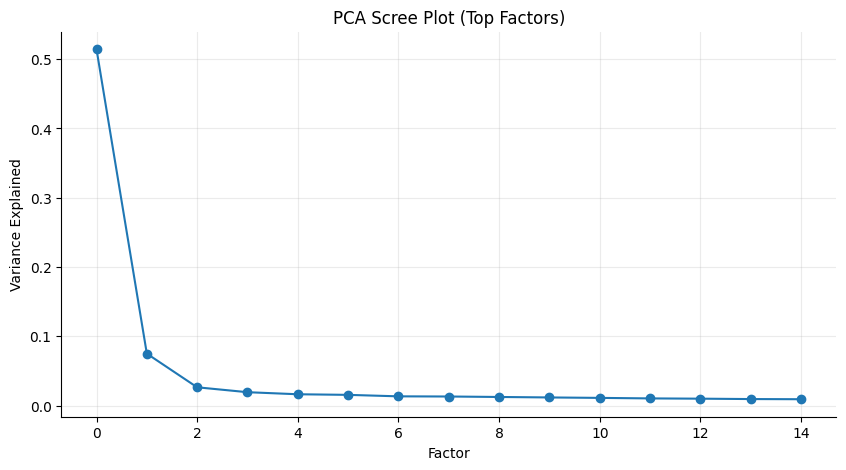

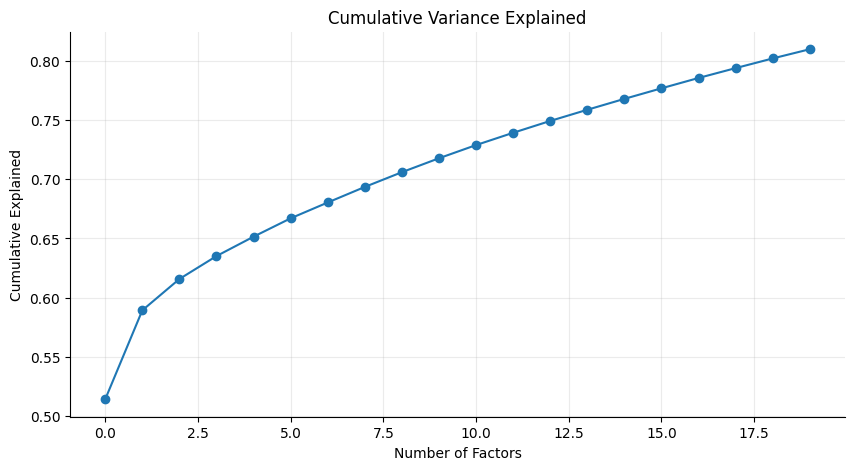

In [26]:
# =========================
# BLOCK 2: SAMPLE PCA SNAPSHOT
# =========================

def build_rolling_snapshot(i):
    window_slice = returns_np[i - PCA_LOOKBACK + 1 : i + 1, :]
    valid_mask = ~np.isnan(window_slice).any(axis=0)

    if valid_mask.sum() < N_PCA_FACTORS + 1:
        return None

    window_data = window_slice[:, valid_mask]
    valid_col_idx = np.where(valid_mask)[0]
    valid_col_names = col_names[valid_col_idx]

    mu = np.mean(window_data, axis=0)
    sigma_raw = np.std(window_data, axis=0, ddof=1)

    sigma_mask = np.isfinite(sigma_raw) & (sigma_raw > 0)
    window_data = window_data[:, sigma_mask]
    sigma = sigma_raw[sigma_mask]
    valid_col_idx = valid_col_idx[sigma_mask]
    valid_col_names = valid_col_names[sigma_mask]

    if window_data.shape[1] < N_PCA_FACTORS + 1:
        return None

    Y = (window_data - mu[sigma_mask]) / sigma
    corr = np.corrcoef(Y, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(corr)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    V = eigvecs[:, :N_PCA_FACTORS]
    Q_load = V / sigma[:, None]
    F_all = window_data @ Q_load

    reg_window = window_data[-OU_WINDOW:, :]
    F_reg = F_all[-OU_WINDOW:, :]
    X_factor = sm.add_constant(F_reg, has_constant="add")
    factor_today = F_all[-1, :]

    explained = eigvals / eigvals.sum()

    return {
        "i": i,
        "date": returns.index[i],
        "window_data": window_data,
        "valid_col_idx": valid_col_idx,
        "valid_col_names": valid_col_names,
        "sigma": sigma,
        "eigvals": eigvals,
        "explained": explained,
        "Q_load": Q_load,
        "F_all": F_all,
        "reg_window": reg_window,
        "F_reg": F_reg,
        "X_factor": X_factor,
        "factor_today": factor_today
    }
snapshot = build_rolling_snapshot(DEBUG_I)

if snapshot is None:
    print("Snapshot failed: not enough valid names")

else:
    print("=== SNAPSHOT INFO ===")
    print(f"date                 : {snapshot['date']}")
    print(f"valid stocks         : {len(snapshot['valid_col_names'])}")
    print(f"window shape         : {snapshot['window_data'].shape}")
    print(f"reg window shape     : {snapshot['reg_window'].shape}")

    print("\n=== PCA QUALITY ===")
    print(f"Top 5 var explained  : {np.round(snapshot['explained'][:5], 4)}")
    print(f"Total (top {N_PCA_FACTORS}) : {snapshot['explained'][:N_PCA_FACTORS].sum():.4f}")

    print("\n=== DATA SANITY ===")
    print(f"window mean          : {np.mean(snapshot['window_data']):.6f}")
    print(f"window std           : {np.std(snapshot['window_data']):.6f}")
    print(f"sigma range          : [{snapshot['sigma'].min():.6f}, {snapshot['sigma'].max():.6f}]")

    print("\n=== CORRELATION CHECK ===")
    corr = np.corrcoef(snapshot["window_data"], rowvar=False)
    print(f"corr mean            : {np.mean(corr):.4f}")
    print(f"corr min/max         : [{corr.min():.4f}, {corr.max():.4f}]")

    print("\n=== FACTOR CHECK ===")
    print(f"factor_today mean    : {np.mean(snapshot['factor_today']):.6f}")
    print(f"factor_today std     : {np.std(snapshot['factor_today']):.6f}")

    print("-" * 50)

    # ===== GRAPH 1: Scree Plot =====
    plt.figure()
    plt.plot(snapshot["explained"][:15], marker="o")
    plt.title("PCA Scree Plot (Top Factors)")
    plt.xlabel("Factor")
    plt.ylabel("Variance Explained")
    plt.show()

    # ===== GRAPH 2: Cumulative Explained =====
    plt.figure()
    plt.plot(np.cumsum(snapshot["explained"][:20]), marker="o")
    plt.title("Cumulative Variance Explained")
    plt.xlabel("Number of Factors")
    plt.ylabel("Cumulative Explained")
    plt.show()



=== TOP 3 DEBUG STOCKS ===
   stock        r2  resid_std     X_std
0   ADBE  0.914383   0.007296  0.028539
46  MSFT  0.907807   0.006839  0.015025
5   AMAT  0.884221   0.009978  0.030404


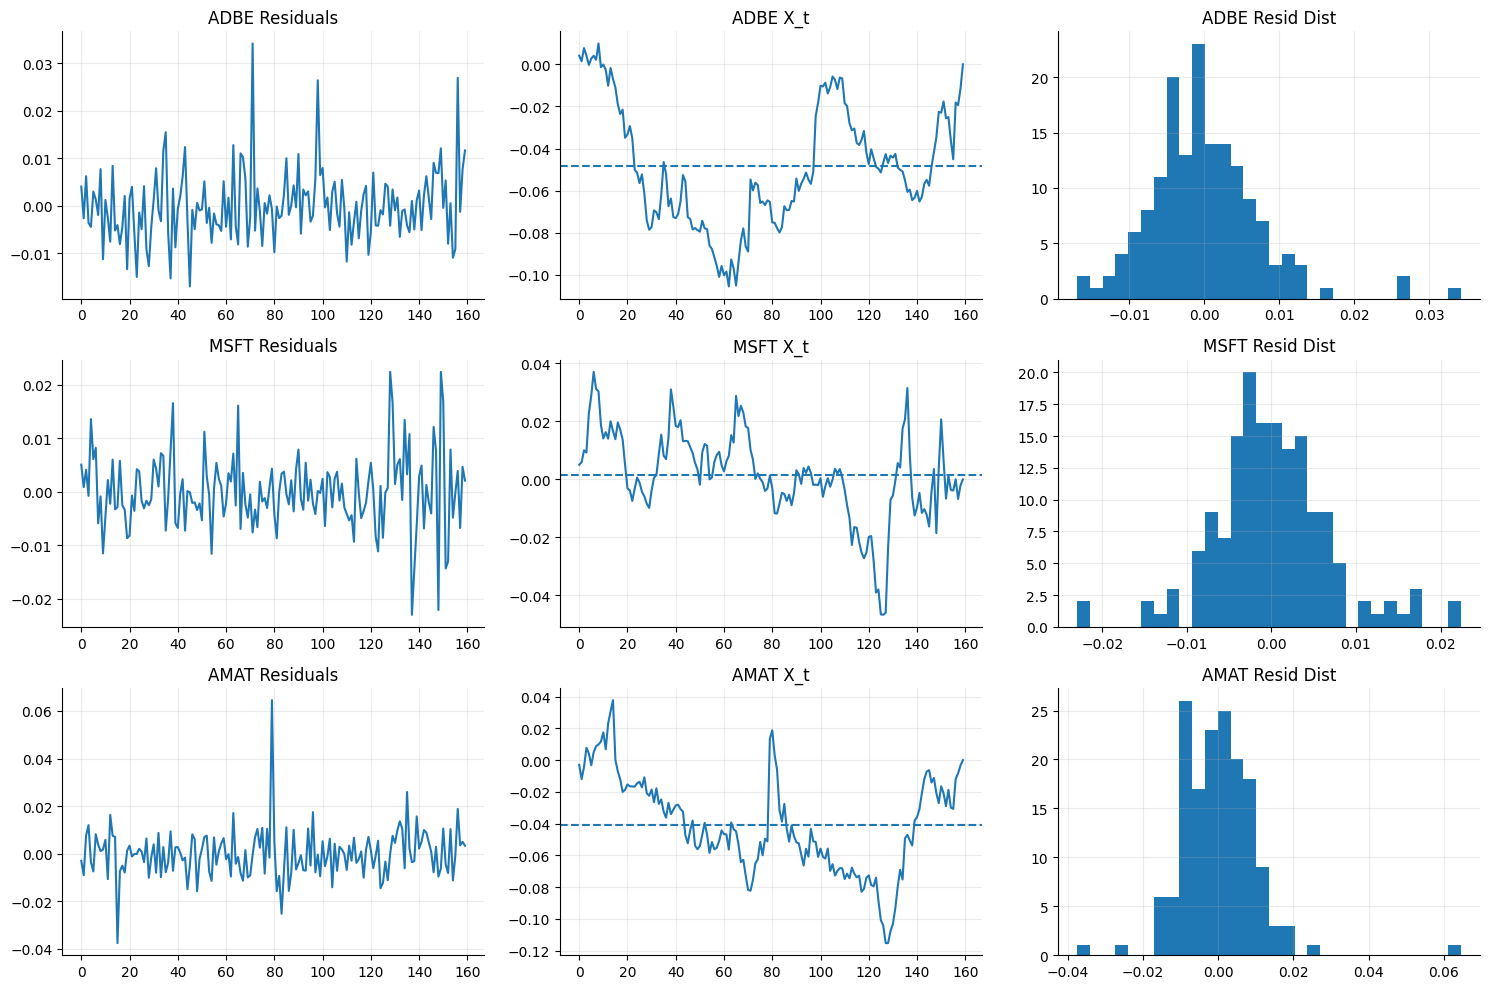

In [27]:
# =========================
# BLOCK 3: SINGLE-STOCK RESIDUAL DIAGNOSTIC
# =========================

if snapshot is None:
    print("Run Block 2 first")

else:
    results = []

    # evaluate all stocks
    for j, stock in enumerate(snapshot["valid_col_names"]):
        y = snapshot["reg_window"][:, j]

        try:
            model = sm.OLS(y, snapshot["X_factor"]).fit()
            resid = model.resid
            X = np.cumsum(resid)

            results.append({
                "stock": stock,
                "j": j,
                "r2": model.rsquared,
                "resid_std": np.std(resid),
                "X_std": np.std(X)
            })

        except:
            continue

    df_res = pd.DataFrame(results)

    # pick top 3 by R² (good structure)
    top3 = df_res.sort_values("r2", ascending=False).head(3)

    print("=== TOP 3 DEBUG STOCKS ===")
    print(top3[["stock", "r2", "resid_std", "X_std"]])

    # ===== PLOT SIDE-BY-SIDE =====
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))

    for row, (_, r) in enumerate(top3.iterrows()):
        j = int(r["j"])
        stock = r["stock"]

        y = snapshot["reg_window"][:, j]
        model = sm.OLS(y, snapshot["X_factor"]).fit()
        resid = model.resid
        X = np.cumsum(resid)

        # Residuals
        axes[row, 0].plot(resid)
        axes[row, 0].set_title(f"{stock} Residuals")

        # Spread X_t
        axes[row, 1].plot(X)
        axes[row, 1].axhline(np.mean(X), linestyle="--")
        axes[row, 1].set_title(f"{stock} X_t")

        # Histogram
        axes[row, 2].hist(resid, bins=30)
        axes[row, 2].set_title(f"{stock} Resid Dist")

    plt.tight_layout()
    plt.show()

compute_stock_signal() loaded

=== KALMAN TIME-SERIES DEBUG ===
          m_t       B_t      kappa  sigma_eq         s
195  0.007476  0.890894  29.113487  0.015816  4.145811
196  0.007886  0.916513  21.969242  0.018039  4.338961
197  0.008315  0.899961  26.561791  0.016466  4.753054
198  0.008720  0.898891  26.861698  0.016459  4.729042
199  0.009095  0.902309  25.905064  0.016699  4.476259

=== SIGNAL STATS ===
count              : 200
s mean / std       : 1.0816 / 1.7594
s min / max        : [-1.31, 5.43]

=== KAPPA CHECK ===
kappa mean         : 10.20
kappa min / max    : [4.72, 29.11]

=== B PARAM CHECK ===
B mean             : 0.9605
B min / max        : [0.8909, 0.9815]

=== SIGMA_EQ CHECK ===
sigma_eq mean      : 0.033364

=== FILTER CHECK ===
K mean             : 0.027433
P_level mean       : 0.000197
--------------------------------------------------


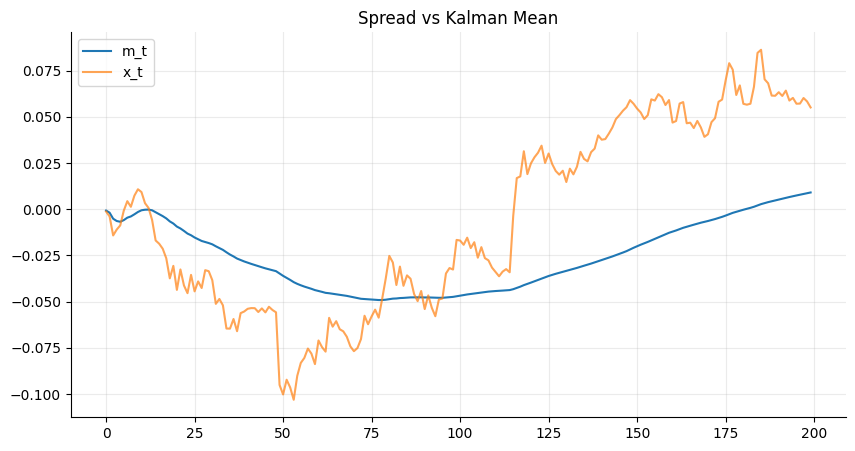

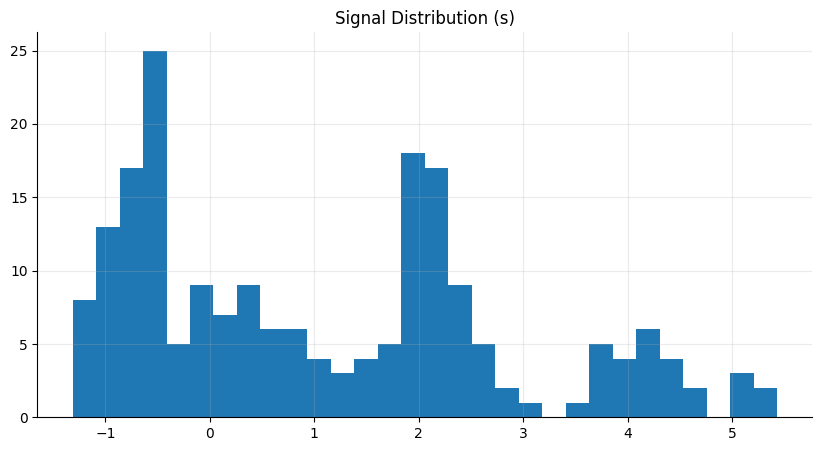

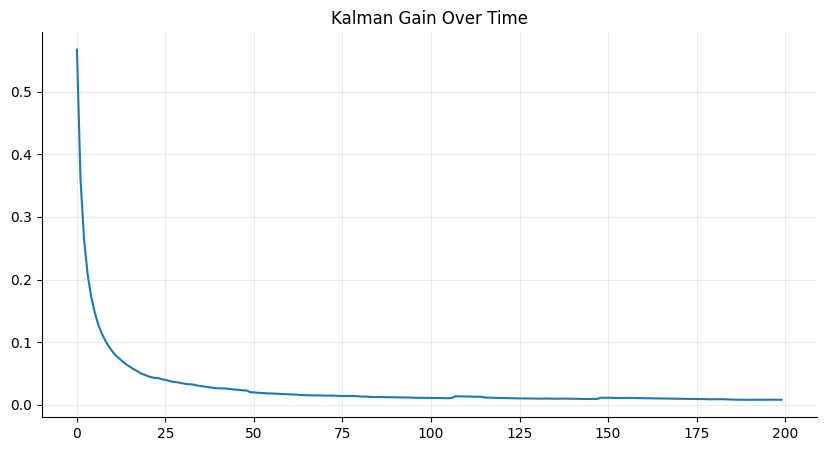

In [28]:
# =========================
# BLOCK 4A: PER-STOCK KALMAN SIGNAL FUNCTION
# =========================

def compute_stock_signal(j, stock, snapshot, kf_state, X_history):
    y_hist = snapshot["reg_window"][:, j]

    model = sm.OLS(y_hist, snapshot["X_factor"]).fit()
    alpha = float(model.params[0])
    betas = np.asarray(model.params[1:], dtype=float)

    if stock not in kf_state:
        kf_state[stock] = init_kf()

    if X_history is not None and stock not in X_history:
        X_history[stock] = []

    state = kf_state[stock]

    # today's residual and spread level
    y_today = float(snapshot["reg_window"][-1, j])
    factor_today = np.asarray(snapshot["factor_today"], dtype=float)
    resid_today = y_today - (alpha + factor_today @ betas)

    x_prev = float(state.get("x_prev", 0.0))
    x_t = x_prev + resid_today
    X_history[stock].append(x_t)

    # ===== MEAN-ONLY KALMAN =====
    if "m_level" not in state:
        state["m_level"] = 0.0
        state["P_level"] = KF_INIT_VAR

    m_prev = float(state["m_level"])
    P_prev = float(state["P_level"])

    # local-level filter
    R = P_prev / DELTA_A

    # observation variance from current regression residual window
    obs_resid = y_hist - model.fittedvalues
    resid_var = float(np.var(obs_resid, ddof=1))

    # correct scaling for cumulative spread
    obs_var = resid_var * len(y_hist) * 0.5
    

    if not np.isfinite(obs_var) or obs_var <= 1e-12:
        return None, betas, None

    Q = R + obs_var
    K = R / Q

    m_t = m_prev + K * (x_t - m_prev)
    P_t = (1.0 - K) * R

    state["m_level"] = m_t
    state["P_level"] = P_t
    state["x_prev"] = x_t

    # ===== STATIC OU PARAMS =====
    # ===== STATIC OU PARAMS FROM CURRENT ROLLING WINDOW =====
    resid_hist = y_hist - model.fittedvalues
    X_series = np.cumsum(resid_hist)

    if len(X_series) < 20:
        return None, betas, None

    X_lag = X_series[:-1]
    X_next = X_series[1:]

    ou_model = sm.OLS(X_next, sm.add_constant(X_lag)).fit()
    a_static, b_static = map(float, ou_model.params)

    if not np.isfinite(b_static) or b_static <= 0 or b_static >= 0.999:
        return None, betas, None

    eps = X_next - (a_static + b_static * X_lag)
    sigma_eps = float(np.std(eps, ddof=1))

    sigma_eq = sigma_eps / np.sqrt(1.0 - b_static**2)

    if not np.isfinite(sigma_eq) or sigma_eq <= 1e-12:
        return None, betas, None

    B_t = b_static
    kappa = -np.log(B_t) * 252.0

    # ===== SIGNAL =====
    d_t = x_t - m_t
    # dynamic volatility (last 60 points of X_t)
    if len(X_history[stock]) > 60:
        sigma_dyn = np.std(X_history[stock][-60:])
    else:
        sigma_dyn = sigma_eq

    if sigma_dyn <= 1e-12 or not np.isfinite(sigma_dyn):
        return None, betas, None

    s = d_t / sigma_dyn

    if not np.isfinite(s):
        return None, betas, None
    
    m_pred = m_prev
    nu_t = x_t - m_pred

    debug = {
        "stock": stock,
        "x_t": x_t,
        "m_t": m_t,
        "B_t": B_t,
        "kappa": kappa,
        "sigma_eq": sigma_eq,
        "d_t": d_t,
        "s": s,
        "P_level": P_t,
        "K": K,
        "resid_today": resid_today,
        "innovation_var": Q,
        "m_pred": m_prev,
        "nu_t": nu_t,
        "post_err": x_t - m_t,
    }

    return s, betas, debug


print("compute_stock_signal() loaded")


# =========================
# FIXED DEBUG (TIME SERIES)
# =========================

print("\n=== KALMAN TIME-SERIES DEBUG ===")

if snapshot is not None:

    test_stock = snapshot["valid_col_names"][0]

    kf_state_test = {}
    X_history_test = {}
    rows = []

    for i in valid_pos[:200]:
        snap = build_rolling_snapshot(i)
        if snap is None or test_stock not in snap["valid_col_names"]:
            continue

        j = np.where(snap["valid_col_names"] == test_stock)[0][0]

        s, betas, dbg = compute_stock_signal(
            j, test_stock, snap, kf_state_test, X_history_test
        )

        if dbg is not None:
            rows.append(dbg)

    df_dbg = pd.DataFrame(rows)

    print(df_dbg[["m_t", "B_t", "kappa", "sigma_eq", "s"]].tail())

    print("\n=== SIGNAL STATS ===")
    print(f"count              : {len(df_dbg)}")
    print(f"s mean / std       : {df_dbg['s'].mean():.4f} / {df_dbg['s'].std():.4f}")
    print(f"s min / max        : [{df_dbg['s'].min():.2f}, {df_dbg['s'].max():.2f}]")

    print("\n=== KAPPA CHECK ===")
    print(f"kappa mean         : {df_dbg['kappa'].mean():.2f}")
    print(f"kappa min / max    : [{df_dbg['kappa'].min():.2f}, {df_dbg['kappa'].max():.2f}]")

    print("\n=== B PARAM CHECK ===")
    print(f"B mean             : {df_dbg['B_t'].mean():.4f}")
    print(f"B min / max        : [{df_dbg['B_t'].min():.4f}, {df_dbg['B_t'].max():.4f}]")

    print("\n=== SIGMA_EQ CHECK ===")
    print(f"sigma_eq mean      : {df_dbg['sigma_eq'].mean():.6f}")

    print("\n=== FILTER CHECK ===")
    print(f"K mean             : {df_dbg['K'].mean():.6f}")
    print(f"P_level mean       : {df_dbg['P_level'].mean():.6f}")

    print("-" * 50)

    plt.figure()
    plt.plot(df_dbg["m_t"], label="m_t")
    plt.plot(df_dbg["x_t"], label="x_t", alpha=0.7)
    plt.title("Spread vs Kalman Mean")
    plt.legend()
    plt.show()

    plt.figure()
    plt.hist(df_dbg["s"], bins=30)
    plt.title("Signal Distribution (s)")
    plt.show()

    plt.figure()
    plt.plot(df_dbg["K"])
    plt.title("Kalman Gain Over Time")
    plt.show()

In [29]:
# =========================
# BLOCK 4B: KALMAN VS SPREAD
# =========================
if len(X_history) == 0:
    print("X_history is empty. Run backtest first.")

else:
    stock = list(X_history.keys())[0]
    X = np.array(X_history[stock])

    if len(X) < 60:
        print(f"{stock} not enough history")

    else:
        state = init_kf()
        x_prev = 0.0

        m_vals = []
        d_vals = []

        for x_t in X:
            F_t = np.array([1.0, x_prev])
            m_prev = state["m"]
            P_prev = state["P"]

            W = np.diag([
                ((1 - delta_A) / delta_A) * max(P_prev[0, 0], 1e-8),
                ((1 - delta_B) / delta_B) * max(P_prev[1, 1], 1e-8)
            ])

            R = P_prev + W
            a_t = m_prev

            # ===== FIX 1: CLIP innovation =====
            e_t = x_t - (F_t @ a_t)
            e_t = np.clip(e_t, -0.05, 0.05)

            q_t = F_t @ R @ F_t.T + 1.0
            K_t = (R @ F_t) / q_t

            m_new = a_t + K_t * e_t
            P_new = R - np.outer(K_t, K_t) * q_t

            state["m"] = m_new
            state["P"] = P_new

            A_t, B_t = m_new

            # ===== FIX 2: CLIP A_t =====
            A_t = np.clip(A_t, -0.05, 0.05)

            B_t = min(B_t, 0.999)

            # ===== FIX 3: STABLE DENOM =====
            mean_denom = max(0.05, 1.0 - B_t)
            m_eq = A_t / mean_denom

            m_vals.append(m_eq)
            d_vals.append(x_t - m_eq)

            x_prev = x_t

        print("=== KALMAN VS SPREAD ===")
        print(f"stock               : {stock}")
        print(f"length              : {len(X)}")
        print(f"avg |deviation|     : {np.nanmean(np.abs(d_vals)):.4f}")
        print(f"max |deviation|     : {np.nanmax(np.abs(d_vals)):.4f}")
        print("-" * 50)

        # ===== GRAPH 1: Spread vs Mean =====
        plt.figure()
        plt.plot(X, label="X_t")
        plt.plot(m_vals, label="Kalman Mean")
        plt.title(f"{stock} Spread vs Mean")
        plt.legend()
        plt.show()

        # ===== GRAPH 2: Deviation =====
        plt.figure()
        plt.plot(d_vals)
        plt.axhline(0, linestyle="--")
        plt.title(f"{stock} Deviation (X_t - Mean)")
        plt.xlabel("Time")
        plt.ylabel("Deviation")
        plt.show()



X_history is empty. Run backtest first.


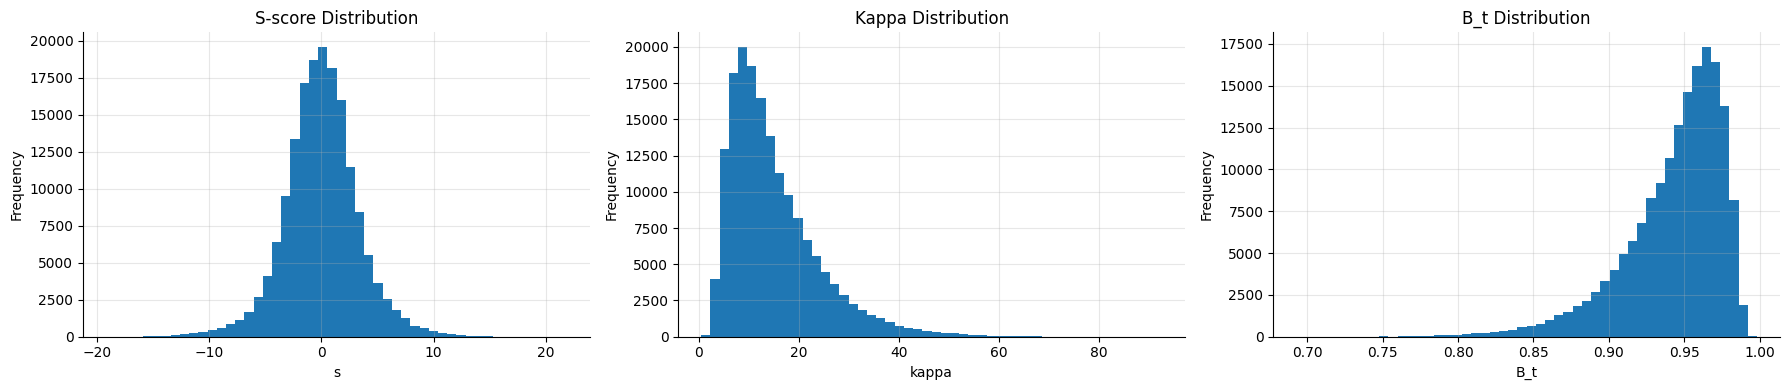

S-score mean: 0.006010180185937776
S-score std : 3.3043829322950566
Mean B_t    : 0.9429822922131555
Mean kappa  : 14.954963257808423


In [30]:
# =========================
# BLOCK 4C: SIGNAL DIAGNOSTICS
# =========================

if "debug_df" not in globals() or debug_df.empty:
    print("debug_df is missing or empty. Run the backtest/report block first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(debug_df["s"], bins=50)
    axes[0].set_title("S-score Distribution")
    axes[0].set_xlabel("s")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(debug_df["kappa"], bins=50)
    axes[1].set_title("Kappa Distribution")
    axes[1].set_xlabel("kappa")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, alpha=0.3)

    axes[2].hist(debug_df["B_t"], bins=50)
    axes[2].set_title("B_t Distribution")
    axes[2].set_xlabel("B_t")
    axes[2].set_ylabel("Frequency")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    s_vals = debug_df["s"]
    print("S-score mean:", s_vals.mean())
    print("S-score std :", s_vals.std())
    print("Mean B_t    :", debug_df["B_t"].mean())
    print("Mean kappa  :", debug_df["kappa"].mean())


=== POSITION RULE DEBUG ===
signals count       : 50
positions opened    : 0
longs / shorts      : 0 / 0

=== SIGNAL RANGE ===
mean / std          : 0.0067 / 0.1986
min / max           : [-0.43, 0.72]


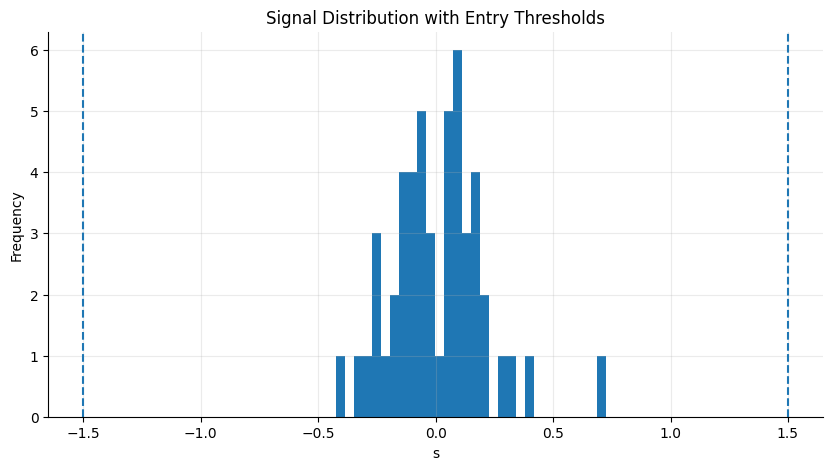

In [31]:
# =========================
# BLOCK 5: POSITION RULES
# =========================

def update_positions(positions, s_values, tradable_names=None):
    new_positions = positions.copy()

    if tradable_names is not None:
        for stock in list(new_positions.keys()):
            if stock not in tradable_names:
                new_positions.pop(stock)

    for stock, s in s_values.items():
        pos = new_positions.get(stock, 0)

        if pos == 0:
            if s < -ENTRY_THRESHOLD:
                new_positions[stock] = 1
            elif s > ENTRY_THRESHOLD:
                new_positions[stock] = -1

        elif pos == 1 and s > -LONG_EXIT_THRESHOLD:
            new_positions.pop(stock)

        elif pos == -1 and s < SHORT_EXIT_THRESHOLD:
            new_positions.pop(stock)

    return new_positions

print("\n=== POSITION RULE DEBUG ===")

if snapshot is not None:

    s_values_test = {}

    # build sample signals
    for j, stock in enumerate(snapshot["valid_col_names"][:50]):
        s, betas, dbg = compute_stock_signal(j, stock, snapshot, kf_state, X_history)
        if s is not None:
            s_values_test[stock] = s

    new_pos = update_positions({}, s_values_test)

    longs = sum(1 for v in new_pos.values() if v == 1)
    shorts = sum(1 for v in new_pos.values() if v == -1)

    print(f"signals count       : {len(s_values_test)}")
    print(f"positions opened    : {len(new_pos)}")
    print(f"longs / shorts      : {longs} / {shorts}")

    if len(s_values_test) > 0:
        s_array = np.array(list(s_values_test.values()))

        print("\n=== SIGNAL RANGE ===")
        print(f"mean / std          : {s_array.mean():.4f} / {s_array.std():.4f}")
        print(f"min / max           : [{s_array.min():.2f}, {s_array.max():.2f}]")

        # ===== GRAPH: Signal Distribution with thresholds =====
        plt.figure()
        plt.hist(s_array, bins=30)
        plt.axvline(ENTRY_THRESHOLD, linestyle="--")
        plt.axvline(-ENTRY_THRESHOLD, linestyle="--")
        plt.title("Signal Distribution with Entry Thresholds")
        plt.xlabel("s")
        plt.ylabel("Frequency")
        plt.show()

In [32]:
# =========================
# BLOCK 6: PORTFOLIO CONSTRUCTION
# =========================

def build_target_weights(positions, beta_dict):
    longs = [name for name, p in positions.items() if p == 1]
    shorts = [name for name, p in positions.items() if p == -1]

    target_weights = {}
    active_names = longs + shorts
    n_active = len(active_names)

    if n_active > 0:
        w = 1.0 / n_active

        for stock in longs:
            target_weights[stock] = +w

        for stock in shorts:
            target_weights[stock] = -w

        factor_exposure = np.zeros(N_PCA_FACTORS, dtype=float)

        for stock in active_names:
            beta = beta_dict.get(stock)
            if beta is None:
                continue
            factor_exposure += target_weights[stock] * np.asarray(beta, dtype=float)

        for k in range(N_PCA_FACTORS):
            hedge_name = f"FACTOR_{k}"
            target_weights[hedge_name] = -factor_exposure[k]

        # normalize to fixed gross leverage
        gross = sum(abs(wgt) for wgt in target_weights.values())
        if gross > 1e-12:
            scale = TARGET_GROSS / gross
            for name in target_weights:
                target_weights[name] *= scale

    return target_weights, longs, shorts, active_names

print("\n=== PORTFOLIO DEBUG ===")

if snapshot is not None:

    # build sample signals
    s_values_test = {}
    beta_dict_test = {}

    for j, stock in enumerate(snapshot["valid_col_names"][:50]):
        s, betas, dbg = compute_stock_signal(j, stock, snapshot, kf_state, X_history)
        if s is not None:
            s_values_test[stock] = s
            beta_dict_test[stock] = betas

    positions_test = update_positions({}, s_values_test)

    weights, longs, shorts, active = build_target_weights(positions_test, beta_dict_test)

    print(f"active positions     : {len(active)}")
    print(f"longs / shorts       : {len(longs)} / {len(shorts)}")

    if len(weights) > 0:
        gross = sum(abs(w) for w in weights.values())
        print(f"gross leverage       : {gross:.4f}")

        # ===== FACTOR EXPOSURE CHECK =====
        factor_exposure = np.zeros(N_PCA_FACTORS)

        for name, w in weights.items():
            if name.startswith("FACTOR_"):
                continue
            beta = beta_dict_test.get(name)
            if beta is not None:
                factor_exposure += w * np.asarray(beta)

        print("\n=== FACTOR EXPOSURE (should be ~0) ===")
        print(f"mean abs exposure    : {np.mean(np.abs(factor_exposure)):.6f}")
        print(f"max abs exposure     : {np.max(np.abs(factor_exposure)):.6f}")

        print("-" * 50)

        # ===== GRAPH: Weight Distribution =====
        w_vals = np.array(list(weights.values()))

        plt.figure()
        plt.hist(w_vals, bins=30)
        plt.title("Portfolio Weight Distribution")
        plt.xlabel("Weight")
        plt.ylabel("Frequency")
        plt.show()


=== PORTFOLIO DEBUG ===
active positions     : 0
longs / shorts       : 0 / 0



=== PNL DEBUG ===
active positions     : 1
longs / shorts       : 0 / 1
one-day pnl          : -0.289650

=== PNL STATS ===
mean / std           : -0.001793 / 0.015257
min / max            : [-0.0729, 0.0466]


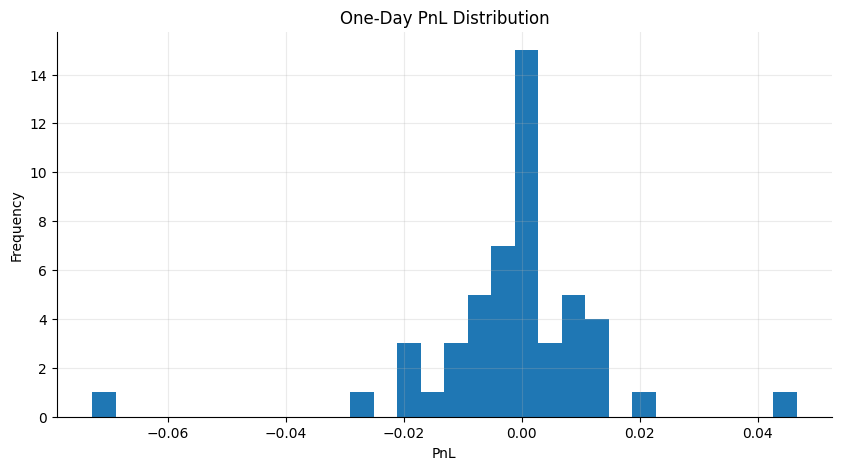

In [33]:
# =========================
# BLOCK 7: ONE-DAY PNL FUNCTION
# =========================

def compute_one_day_pnl(i, snapshot, target_weights):
    if i + 1 >= len(returns_np):
        return None

    next_ret = returns_np[i + 1]
    gross_pnl = 0.0

    valid_idx = snapshot["valid_col_idx"]
    valid_next_ret = next_ret[valid_idx]

    for name, wgt in target_weights.items():

        # single-stock leg
        if name in col_index_map:
            r = next_ret[col_index_map[name]]
            if np.isfinite(r):
                gross_pnl += wgt * r

        # factor hedge leg
        elif name.startswith("FACTOR_"):
            k = int(name.split("_")[1])

            finite_mask = np.isfinite(valid_next_ret)
            if finite_mask.sum() == 0:
                continue

            factor_ret = valid_next_ret[finite_mask] @ snapshot["Q_load"][finite_mask, k]

            if np.isfinite(factor_ret):
                gross_pnl += wgt * factor_ret

    return gross_pnl

print("\n=== PNL DEBUG ===")

if snapshot is not None:

    s_values_test = {}
    beta_dict_test = {}

    for j, stock in enumerate(snapshot["valid_col_names"][:50]):
        s, betas, dbg = compute_stock_signal(j, stock, snapshot, kf_state, X_history)
        if s is not None:
            s_values_test[stock] = s
            beta_dict_test[stock] = betas

    positions_test = update_positions({}, s_values_test)
    weights, longs, shorts, active = build_target_weights(positions_test, beta_dict_test)

    pnl = compute_one_day_pnl(DEBUG_I, snapshot, weights)

    print(f"active positions     : {len(active)}")
    print(f"longs / shorts       : {len(longs)} / {len(shorts)}")

    if pnl is not None:
        print(f"one-day pnl          : {pnl:.6f}")

    # ===== MULTI-DAY SAMPLE PNL =====
    pnl_samples = []

    for ii in valid_pos[:50]:
        snap = build_rolling_snapshot(ii)
        if snap is None:
            continue

        s_vals = {}
        beta_vals = {}

        for j, stock in enumerate(snap["valid_col_names"][:30]):
            s, betas, dbg = compute_stock_signal(j, stock, snap, kf_state, X_history)
            if s is not None:
                s_vals[stock] = s
                beta_vals[stock] = betas

        pos = update_positions({}, s_vals)
        w, _, _, _ = build_target_weights(pos, beta_vals)

        p = compute_one_day_pnl(ii, snap, w)
        if p is not None:
            pnl_samples.append(p)

    if len(pnl_samples) > 0:
        pnl_arr = np.array(pnl_samples)

        print("\n=== PNL STATS ===")
        print(f"mean / std           : {pnl_arr.mean():.6f} / {pnl_arr.std():.6f}")
        print(f"min / max            : [{pnl_arr.min():.4f}, {pnl_arr.max():.4f}]")

        # ===== GRAPH: PnL Distribution =====
        plt.figure()
        plt.hist(pnl_arr, bins=30)
        plt.title("One-Day PnL Distribution")
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.show()

In [35]:
# =========================
# BLOCK 8: MAIN BACKTEST LOOP
# =========================

# reset outputs/state before full run
pnl_series = []
turnover_series = []
active_count_series = []
long_count_series = []
short_count_series = []

positions = {}
weights_prev = {}
kf_state = {}
X_history = {}

debug_rows = []

for step_num, i in enumerate(valid_pos):

    snapshot = build_rolling_snapshot(i)

    if snapshot is None:
        pnl_series.append(0.0)
        turnover_series.append(0.0)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)
        continue

    s_values = {}
    beta_dict = {}
    local_debug = []

    for j, stock in enumerate(snapshot["valid_col_names"]):
        s, betas, dbg = compute_stock_signal(j, stock, snapshot, kf_state, X_history)

        beta_dict[stock] = betas

        if dbg is not None:
            s_values[stock] = s
            local_debug.append(dbg)

    # empty signal case
    if len(s_values) == 0:
        target_weights = {}

        turnover = sum(
            abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
            for n in set(weights_prev) | set(target_weights)
        )

        trading_cost = TRANSACTION_COST * turnover

        pnl_series.append(-trading_cost)
        turnover_series.append(turnover)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)

        positions = {}
        weights_prev = {}
        continue

    positions = update_positions(
        positions,
        s_values,
        tradable_names=set(snapshot["valid_col_names"])
    )
    target_weights, longs, shorts, active_names = build_target_weights(positions, beta_dict)

    long_count_series.append(len(longs))
    short_count_series.append(len(shorts))

    turnover = sum(
        abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
        for n in set(weights_prev) | set(target_weights)
    )

    trading_cost = TRANSACTION_COST * turnover

    gross_pnl = compute_one_day_pnl(i, snapshot, target_weights)

    if gross_pnl is None:
        pnl_series.append(-trading_cost)
        turnover_series.append(turnover)
        active_count_series.append(len(active_names))
        long_count_series.append(len(longs))
        short_count_series.append(len(shorts))
        weights_prev = target_weights.copy()
        continue

    net_pnl = gross_pnl - trading_cost

    pnl_series.append(net_pnl)
    turnover_series.append(turnover)
    active_count_series.append(len(active_names))

    weights_prev = target_weights.copy()
    debug_rows.extend(local_debug)

    if step_num % 250 == 0:
        avg_abs_s = np.mean(np.abs(list(s_values.values()))) if len(s_values) > 0 else np.nan
        print(
            f"step={step_num:4d} | date={snapshot['date'].date()} | "
            f"signals={len(s_values):3d} | positions={len(active_names):2d} | "
            f"avg|s|={avg_abs_s:.3f} | turnover={turnover:.4f}"
        )

print("Backtest loop finished")
print(f"Stored Kalman states: {len(kf_state)}")
print(f"Stocks with X-history: {len(X_history)}")

step=   0 | date=2019-01-03 | signals= 78 | positions= 0 | avg|s|=0.140 | turnover=0.0000
step= 250 | date=2019-12-31 | signals= 82 | positions=67 | avg|s|=2.176 | turnover=0.1234
step= 500 | date=2020-12-28 | signals= 88 | positions=61 | avg|s|=1.976 | turnover=0.1878
step= 750 | date=2021-12-23 | signals= 93 | positions=70 | avg|s|=2.033 | turnover=0.0568
step=1000 | date=2022-12-21 | signals= 99 | positions=69 | avg|s|=2.338 | turnover=0.0597
step=1250 | date=2023-12-20 | signals= 99 | positions=74 | avg|s|=2.737 | turnover=0.0114
step=1500 | date=2024-12-18 | signals= 99 | positions=75 | avg|s|=2.489 | turnover=0.1072
step=1750 | date=2025-12-18 | signals= 99 | positions=76 | avg|s|=2.656 | turnover=0.0003
Backtest loop finished
Stored Kalman states: 99
Stocks with X-history: 99



========== MODEL REPORT ==========

---- PERFORMANCE ----
Annual Return     : 0.0918
Annual Vol        : 0.0999
Sharpe Ratio      : 0.9191
Max Drawdown      : -0.0984
Calmar Ratio      : 0.9332

---- TRADE QUALITY ----
Win Rate          : 0.5137
Avg Win           : 0.00425
Avg Loss          : -0.00376
Profit Factor     : 1.2001

---- POSITION STATS ----
Avg Longs         : 32.20
Avg Shorts        : 35.95
Avg Positions     : 68.15
Long/Short Ratio  : 0.90
% Days Active     : 1.00

---- ACTIVITY ----
Avg Turnover      : 0.1130
% Trading Days    : 1.00

---- SIGNAL DIAGNOSTICS ----


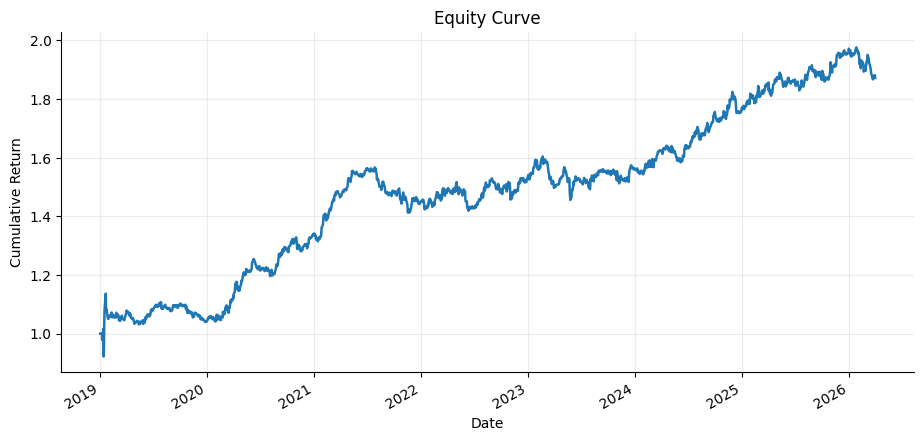

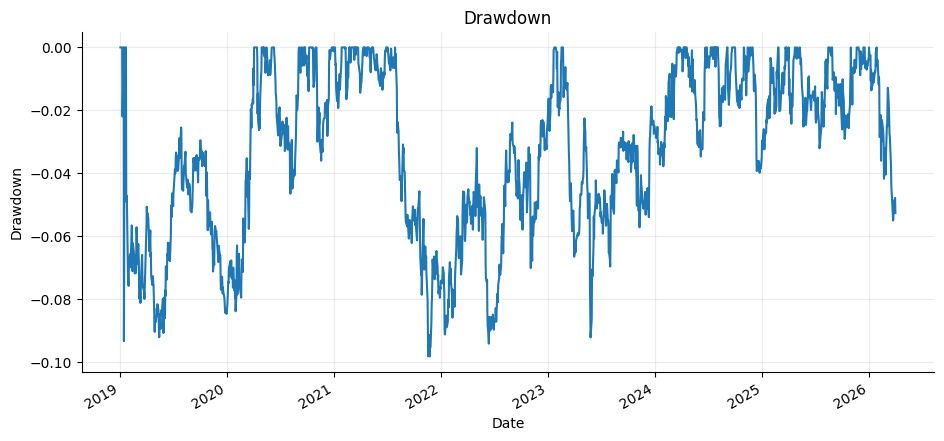

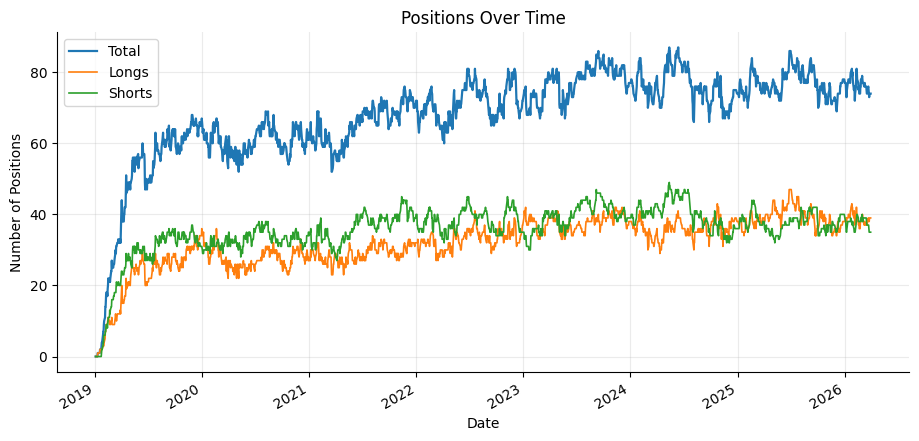

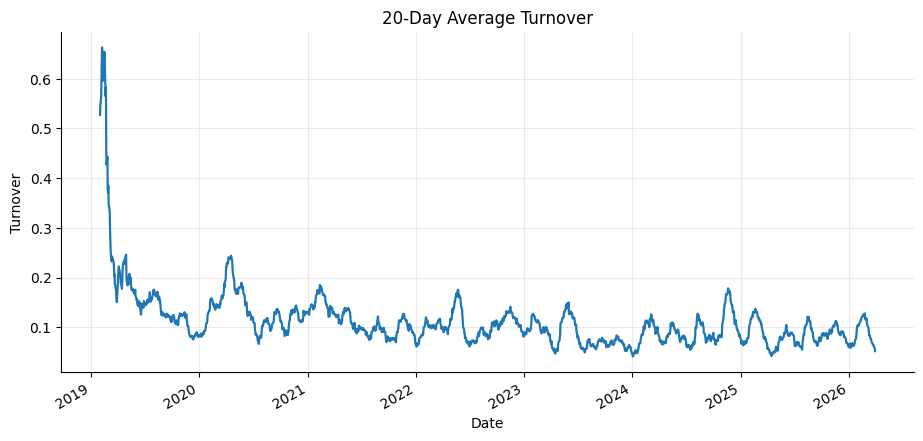

In [36]:
# =========================
# BLOCK 9: OUTPUTS + DIAGNOSTICS
# =========================

out_dates = valid_dates[:len(pnl_series)]

pnl_series = pd.Series(pnl_series, index=out_dates)
turnover_series = pd.Series(turnover_series, index=out_dates)
active_count_series = pd.Series(active_count_series, index=out_dates)
long_count_series = pd.Series(long_count_series, index=out_dates)
short_count_series = pd.Series(short_count_series, index=out_dates)

ret = pnl_series.copy()

mean_daily = ret.mean()
std_daily = ret.std()

ann_factor = 252
mean_annual = mean_daily * ann_factor
vol_annual = std_daily * np.sqrt(ann_factor)
sharpe = mean_annual / vol_annual if vol_annual > 0 else np.nan

cum_returns = (1 + ret).cumprod()
running_max = cum_returns.cummax()
drawdown = cum_returns / running_max - 1
max_dd = drawdown.min()
calmar = mean_annual / abs(max_dd) if max_dd != 0 else np.nan

win_rate = (ret > 0).mean()
avg_win = ret[ret > 0].mean()
avg_loss = ret[ret < 0].mean()

gross_profit = ret[ret > 0].sum()
gross_loss = ret[ret < 0].sum()
profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.nan

avg_longs = long_count_series.mean()
avg_shorts = short_count_series.mean()
avg_positions = active_count_series.mean()
long_short_ratio = avg_longs / avg_shorts if avg_shorts > 0 else np.nan
pct_days_active = (active_count_series > 0).mean()

avg_turnover = turnover_series.mean()
pct_trading_days = (turnover_series > 0).mean()

print("\n========== MODEL REPORT ==========\n")
print("---- PERFORMANCE ----")
print(f"Annual Return     : {mean_annual:.4f}")
print(f"Annual Vol        : {vol_annual:.4f}")
print(f"Sharpe Ratio      : {sharpe:.4f}")
print(f"Max Drawdown      : {max_dd:.4f}")
print(f"Calmar Ratio      : {calmar:.4f}")

print("\n---- TRADE QUALITY ----")
print(f"Win Rate          : {win_rate:.4f}")
print(f"Avg Win           : {avg_win:.5f}")
print(f"Avg Loss          : {avg_loss:.5f}")
print(f"Profit Factor     : {profit_factor:.4f}")

print("\n---- POSITION STATS ----")
print(f"Avg Longs         : {avg_longs:.2f}")
print(f"Avg Shorts        : {avg_shorts:.2f}")
print(f"Avg Positions     : {avg_positions:.2f}")
print(f"Long/Short Ratio  : {long_short_ratio:.2f}")
print(f"% Days Active     : {pct_days_active:.2f}")

print("\n---- ACTIVITY ----")
print(f"Avg Turnover      : {avg_turnover:.4f}")
print(f"% Trading Days    : {pct_trading_days:.2f}")

debug_df = pd.DataFrame(debug_rows)
if len(debug_df) > 0:
    print("\n---- SIGNAL DIAGNOSTICS ----")
    debug_df[["B_t", "kappa", "d_t", "sigma_eq", "s", "K", "P_level"]]
    

# Pretty plots
plt.figure(figsize=(11, 5))
cum_returns.plot(linewidth=1.8)
plt.title("Equity Curve")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()

plt.figure(figsize=(11, 5))
drawdown.plot(linewidth=1.5)
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

plt.figure(figsize=(11, 5))
active_count_series.plot(label="Total", linewidth=1.6)
long_count_series.plot(label="Longs", linewidth=1.2)
short_count_series.plot(label="Shorts", linewidth=1.2)
plt.title("Positions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Positions")
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
turnover_series.rolling(20).mean().plot(linewidth=1.6)
plt.title("20-Day Average Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.show()




========== MODEL HEALTH CHECK ==========

---- CORE STATS ----
Innovation mean           : 0.002068
Innovation std            : 0.133722
|mean| / std              : 0.0155

Standardized innov mean  : 0.007333
Standardized innov std   : 0.907564

Kalman gain mean         : 0.004953
Kalman gain min / max    : [0.000269, 0.728316]

Signal mean              : 0.004841
Signal std               : 2.642008
Signal min / max         : [-15.9604, 15.4221]

B mean                   : 0.943043
B std                    : 0.033063
kappa mean               : 14.938750
kappa std                : 9.082486

---- ADF TEST ON x_t ----
ADF stat                 : -106.843537
ADF p-value              : 0.000000

---- INNOVATION ACF ----
Lag  1 ACF             : -0.0349
Lag  2 ACF             : 0.0019
Lag  3 ACF             : -0.0329
Lag  4 ACF             : 0.0451
Lag  5 ACF             : -0.0079
Lag  6 ACF             : 0.0345
Lag  7 ACF             : 0.0472
Lag  8 ACF             : -0.0049
Lag  9 ACF     

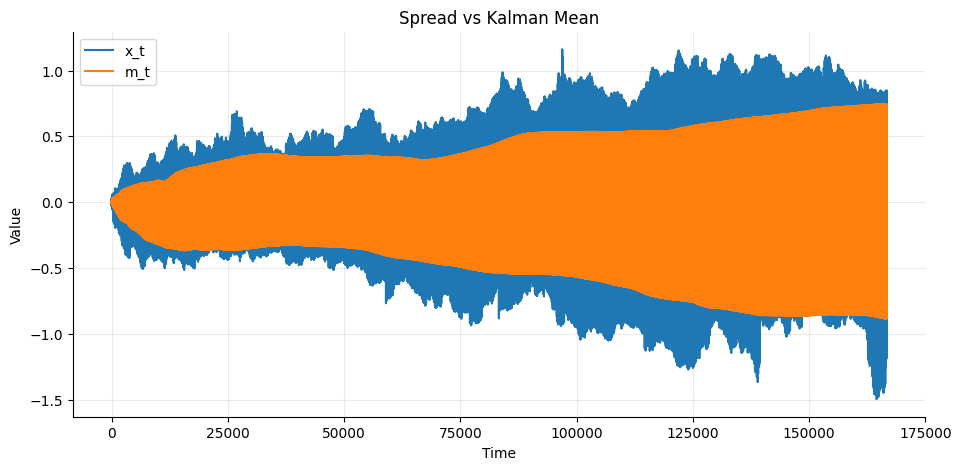

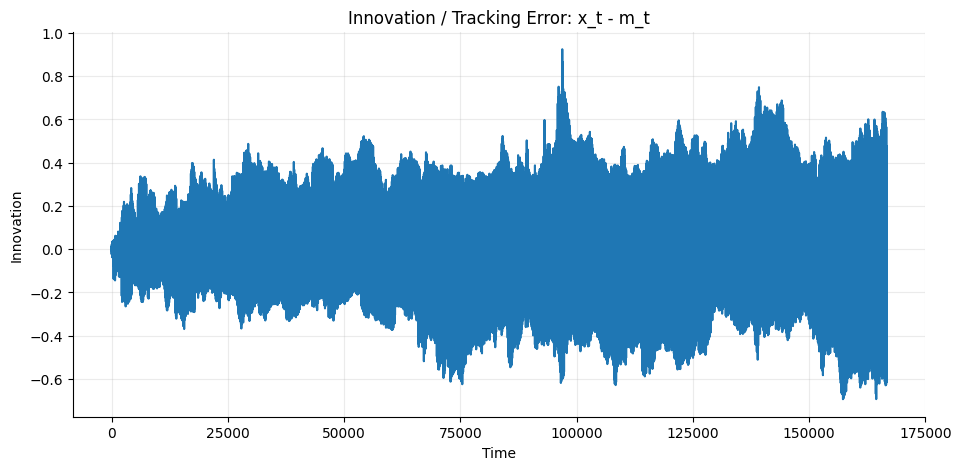

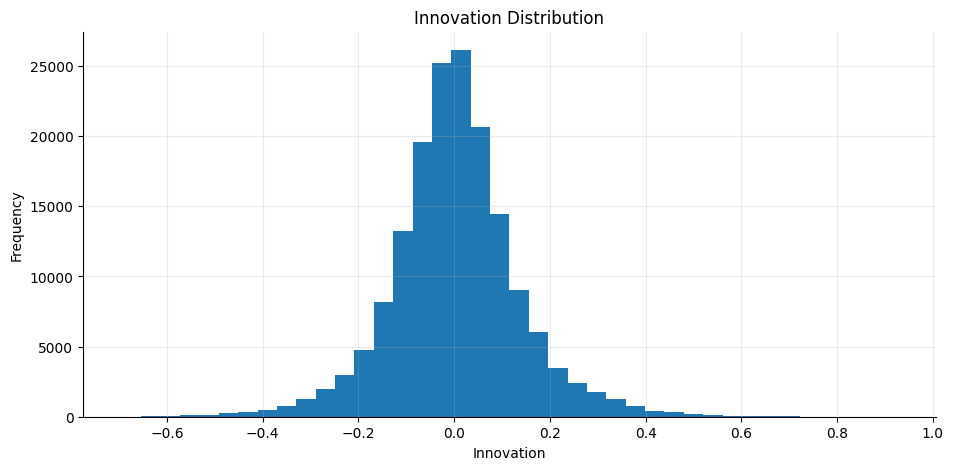

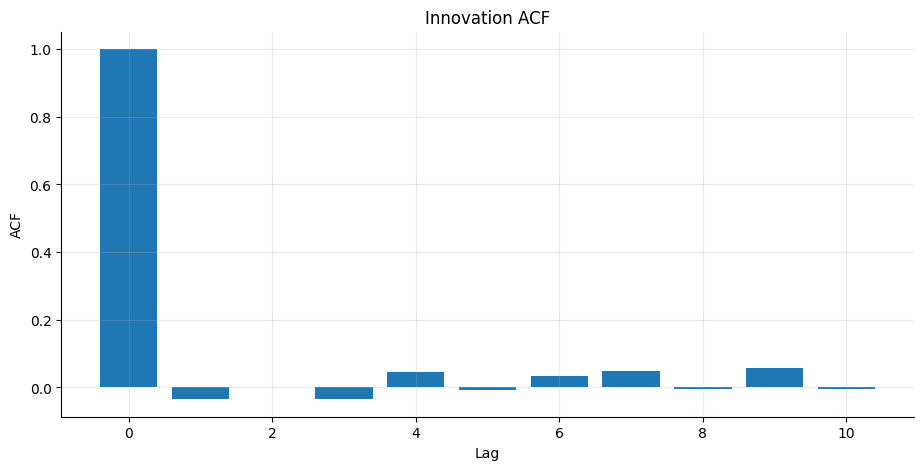

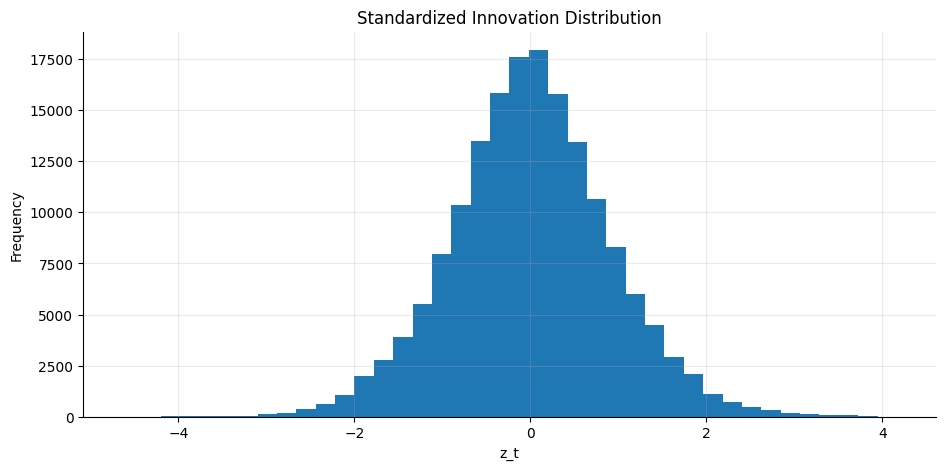

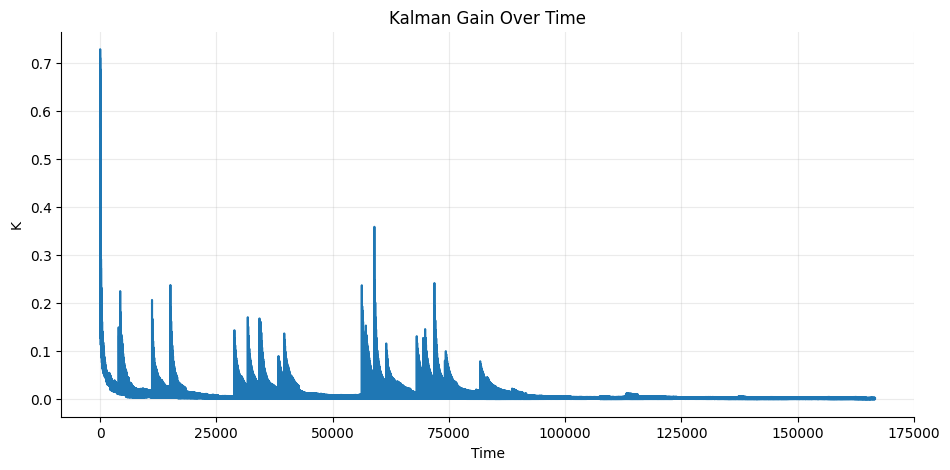

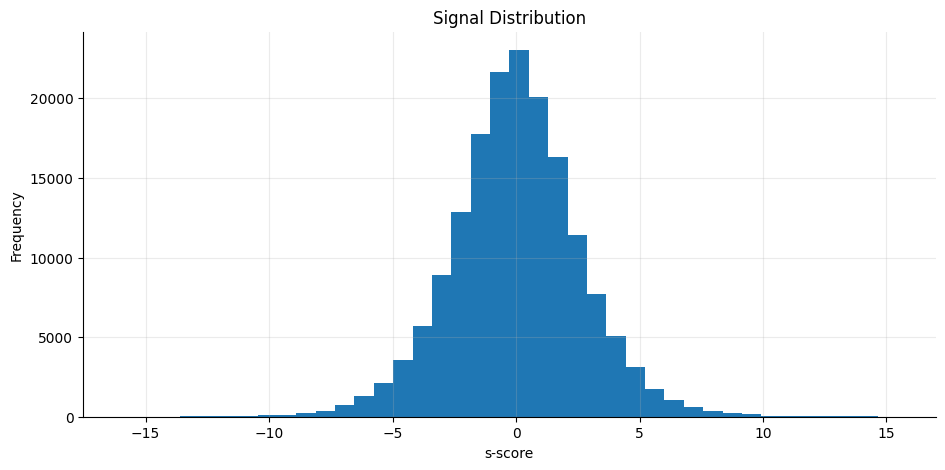

In [ ]:
# =========================
# BLOCK X: MODEL HEALTH CHECK
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, adfuller

print("\n========== MODEL HEALTH CHECK ==========\n")

# ---------------------------------
# 1) Build core series
# ---------------------------------
if len(debug_df) == 0:
    print("No debug rows found.")
else:
    nu = debug_df["x_t"] - debug_df["m_t"]                      # innovation / tracking error
    z = nu / np.sqrt(debug_df["innovation_var"])               # standardized innovation

    # ---------------------------------
    # 2) Summary stats
    # ---------------------------------
    print("---- CORE STATS ----")
    print(f"Innovation mean           : {nu.mean():.6f}")
    print(f"Innovation std            : {nu.std():.6f}")
    print(f"|mean| / std              : {abs(nu.mean()) / nu.std():.4f}" if nu.std() > 0 else "undefined")

    print(f"\nStandardized innov mean  : {z.mean():.6f}")
    print(f"Standardized innov std   : {z.std():.6f}")

    print(f"\nKalman gain mean         : {debug_df['K'].mean():.6f}")
    print(f"Kalman gain min / max    : [{debug_df['K'].min():.6f}, {debug_df['K'].max():.6f}]")

    print(f"\nSignal mean              : {debug_df['s'].mean():.6f}")
    print(f"Signal std               : {debug_df['s'].std():.6f}")
    print(f"Signal min / max         : [{debug_df['s'].min():.4f}, {debug_df['s'].max():.4f}]")

    print(f"\nB mean                   : {debug_df['B_t'].mean():.6f}")
    print(f"B std                    : {debug_df['B_t'].std():.6f}")
    print(f"kappa mean               : {debug_df['kappa'].mean():.6f}")
    print(f"kappa std                : {debug_df['kappa'].std():.6f}")

    # ---------------------------------
    # 3) Stationarity test on spread
    # ---------------------------------
    print("\n---- ADF TEST ON x_t ----")
    adf_stat, adf_pvalue, *_ = adfuller(debug_df["x_t"].dropna())
    print(f"ADF stat                 : {adf_stat:.6f}")
    print(f"ADF p-value              : {adf_pvalue:.6f}")

    # ---------------------------------
    # 4) Innovation autocorrelation
    # ---------------------------------
    acf_vals = acf(nu.dropna(), nlags=10, fft=False)

    print("\n---- INNOVATION ACF ----")
    for lag in range(1, len(acf_vals)):
        print(f"Lag {lag:>2} ACF             : {acf_vals[lag]:.4f}")

    print("\n---- QUICK INTERPRETATION GUIDE ----")
    print("1. Innovation mean should be near 0.")
    print("2. |mean| / std should be very small.")
    print("3. Standardized innovation mean ~ 0 and std ~ 1 is good.")
    print("4. Innovation ACF after lag 0 should be near 0.")
    print("5. Kalman gain should not be near 0 all the time or near 1 all the time.")
    print("6. ADF p-value < 0.05 suggests spread is stationary / mean-reverting.")
    print("7. Signal should be centered near 0 and have enough spread to create trades.")

    # ---------------------------------
    # 5) Plots
    # ---------------------------------
    plt.figure(figsize=(11, 5))
    plt.plot(debug_df["x_t"].values, label="x_t")
    plt.plot(debug_df["m_t"].values, label="m_t")
    plt.title("Spread vs Kalman Mean")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(nu.values)
    plt.title("Innovation / Tracking Error: x_t - m_t")
    plt.xlabel("Time")
    plt.ylabel("Innovation")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.hist(nu.dropna(), bins=40)
    plt.title("Innovation Distribution")
    plt.xlabel("Innovation")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.bar(range(len(acf_vals)), acf_vals)
    plt.title("Innovation ACF")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.hist(z.dropna(), bins=40)
    plt.title("Standardized Innovation Distribution")
    plt.xlabel("z_t")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(debug_df["K"].values)
    plt.title("Kalman Gain Over Time")
    plt.xlabel("Time")
    plt.ylabel("K")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.hist(debug_df["s"].dropna(), bins=40)
    plt.title("Signal Distribution")
    plt.xlabel("s-score")
    plt.ylabel("Frequency")
    plt.show()


========== KALMAN VARIANCE DIAGNOSIS ==========

---- VARIANCE LEVEL CHECK ----
Realized innovation var        : 0.01788154
Mean logged innovation_var Q   : 0.02207335
Median logged innovation_var Q : 0.01639110
Ratio realized / mean_Q        : 0.8101

---- KALMAN GAIN CHECK ----
K mean                         : 0.004953
K median                       : 0.002426
K min / max                    : [0.000269, 0.728316]

---- Q DISTRIBUTION CHECK ----
count    166674.000000
mean          0.022073
std           0.018952
min           0.002012
25%           0.010226
50%           0.016391
75%           0.027062
max           0.241679
Name: innovation_var, dtype: float64


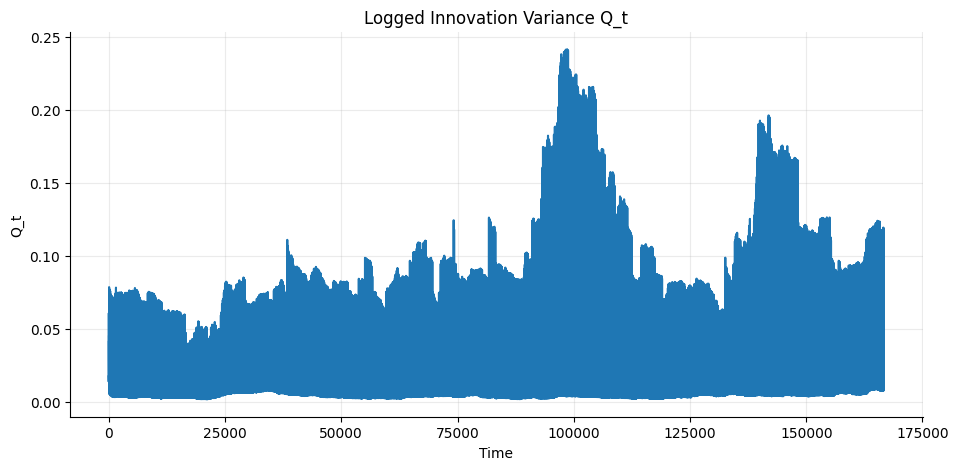

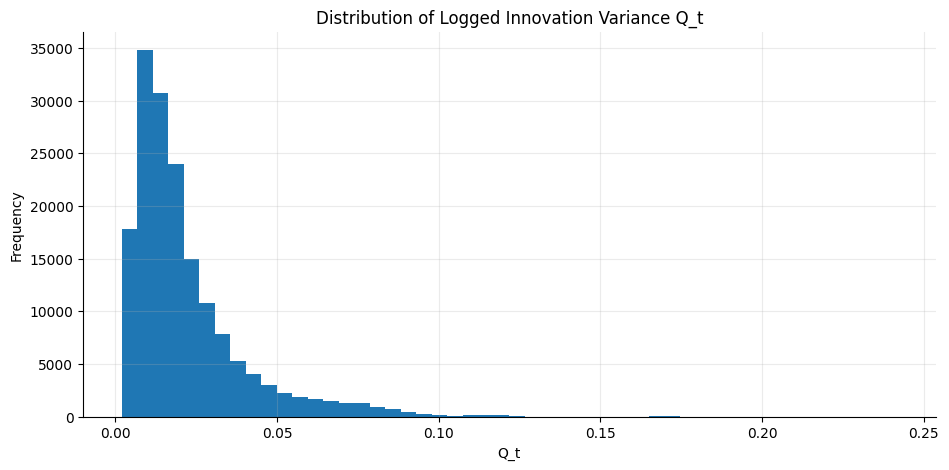

In [ ]:
# =========================
# BLOCK Y: KALMAN VARIANCE DIAGNOSIS
# =========================

print("\n========== KALMAN VARIANCE DIAGNOSIS ==========\n")

if len(debug_df) == 0:
    print("No debug rows found.")
else:
    nu = debug_df["x_t"] - debug_df["m_t"]

    # realized innovation variance
    realized_var = float(np.var(nu, ddof=1))

    # logged forecast variance from filter
    mean_Q = float(debug_df["innovation_var"].mean())
    med_Q = float(debug_df["innovation_var"].median())

    print("---- VARIANCE LEVEL CHECK ----")
    print(f"Realized innovation var        : {realized_var:.8f}")
    print(f"Mean logged innovation_var Q   : {mean_Q:.8f}")
    print(f"Median logged innovation_var Q : {med_Q:.8f}")
    print(f"Ratio realized / mean_Q        : {realized_var / mean_Q:.4f}" if mean_Q > 0 else "undefined")

    print("\n---- KALMAN GAIN CHECK ----")
    print(f"K mean                         : {debug_df['K'].mean():.6f}")
    print(f"K median                       : {debug_df['K'].median():.6f}")
    print(f"K min / max                    : [{debug_df['K'].min():.6f}, {debug_df['K'].max():.6f}]")

    print("\n---- Q DISTRIBUTION CHECK ----")
    print(debug_df["innovation_var"].describe().round(8))

    plt.figure(figsize=(11,5))
    plt.plot(debug_df["innovation_var"].values)
    plt.title("Logged Innovation Variance Q_t")
    plt.xlabel("Time")
    plt.ylabel("Q_t")
    plt.show()

    plt.figure(figsize=(11,5))
    plt.hist(debug_df["innovation_var"].dropna(), bins=50)
    plt.title("Distribution of Logged Innovation Variance Q_t")
    plt.xlabel("Q_t")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
z = debug_df["nu_t"] / np.sqrt(debug_df["innovation_var"])
print(z.mean())
print(z.std())

0.0073263359530099
0.9100659032843036


In [ ]:
# # =========================
# # STAGE 1 ONLY: BROAD BAYESIAN OPTIMIZATION (OPTUNA)
# # =========================

# # pip install optuna tqdm -q

# import time
# import copy
# import warnings
# import numpy as np
# import pandas as pd
# import optuna
# from tqdm.auto import tqdm

# warnings.filterwarnings("ignore")

# # ---------------------------------
# # USER SETTINGS
# # ---------------------------------
# N_TRIALS_STAGE1 = 50
# SEED = 42

# # objective:
# # "sharpe" or "sharpe_dd"
# OBJECTIVE_MODE = "sharpe_dd"

# # minimum viability filters
# MIN_TRADE_DAYS = 80
# MIN_AVG_POSITIONS = 10

# # ---------------------------------
# # METRIC HELPERS
# # ---------------------------------
# def compute_report_from_ret(
# pnl_series,
# turnover_series,
# active_count_series,
# long_count_series,
# short_count_series,
# ):
# ret = pd.Series(pnl_series).dropna()
# if len(ret) == 0:
#     return None

# mean_daily = ret.mean()
# std_daily = ret.std()

# ann_factor = 252
# ann_return = mean_daily * ann_factor
# ann_vol = std_daily * np.sqrt(ann_factor)
# sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan

# cum_returns = (1 + ret).cumprod()
# running_max = cum_returns.cummax()
# drawdown = cum_returns / running_max - 1
# max_dd = drawdown.min()
# calmar = ann_return / abs(max_dd) if abs(max_dd) > 1e-12 else np.nan

# win_rate = (ret > 0).mean()
# avg_win = ret[ret > 0].mean() if (ret > 0).sum() > 0 else np.nan
# avg_loss = ret[ret < 0].mean() if (ret < 0).sum() > 0 else np.nan

# gross_profit = ret[ret > 0].sum()
# gross_loss = ret[ret < 0].sum()
# profit_factor = abs(gross_profit / gross_loss) if abs(gross_loss) > 1e-12 else np.nan

# turnover_series = pd.Series(turnover_series)
# active_count_series = pd.Series(active_count_series)
# long_count_series = pd.Series(long_count_series)
# short_count_series = pd.Series(short_count_series)

# avg_turnover = turnover_series.mean()
# pct_trading_days = (turnover_series > 0).mean()

# avg_positions = active_count_series.mean()
# pct_days_active = (active_count_series > 0).mean()

# avg_longs = long_count_series.mean()
# avg_shorts = short_count_series.mean()
# long_short_ratio = avg_longs / avg_shorts if avg_shorts > 1e-12 else np.nan

# return {
#     "ann_return": ann_return,
#     "ann_vol": ann_vol,
#     "sharpe": sharpe,
#     "max_dd": max_dd,
#     "calmar": calmar,
#     "win_rate": win_rate,
#     "avg_win": avg_win,
#     "avg_loss": avg_loss,
#     "profit_factor": profit_factor,
#     "avg_turnover": avg_turnover,
#     "pct_trading_days": pct_trading_days,
#     "avg_positions": avg_positions,
#     "pct_days_active": pct_days_active,
#     "avg_longs": avg_longs,
#     "avg_shorts": avg_shorts,
#     "long_short_ratio": long_short_ratio,
# }

# def score_from_report(report):
# if report is None:
#     return -1e9

# sharpe = report["sharpe"]
# max_dd = report["max_dd"]
# avg_turnover = report["avg_turnover"]

# if not np.isfinite(sharpe):
#     return -1e9

# if OBJECTIVE_MODE == "sharpe":
#     score = sharpe
# else:
#     # Sharpe - drawdown penalty - small turnover penalty
#     score = sharpe - 0.50 * abs(max_dd) - 0.05 * avg_turnover

# if report["avg_positions"] < MIN_AVG_POSITIONS:
#     score -= 1.0

# return score

# # ---------------------------------
# # BROAD SEARCH SPACE
# # same parameter set as before, broader ranges
# # ---------------------------------
# def sample_stage2(trial):
# params = {
#     # PCA (you’re near optimal already)
#     "N_PCA_FACTORS": trial.suggest_int("N_PCA_FACTORS", 7, 12),

#     # OU window (your best is higher now)
#     "OU_WINDOW": trial.suggest_int("OU_WINDOW", 120, 200, step=20),

#     # ENTRY — tighten around 1.5
#     "ENTRY_THRESHOLD": trial.suggest_float("ENTRY_THRESHOLD", 1.25, 2.00, step=0.1),

#     # EXIT — THIS is where alpha is now
#     "LONG_EXIT_THRESHOLD": trial.suggest_float("LONG_EXIT_THRESHOLD", 0.3, 1.0, step=0.1),
#     "SHORT_EXIT_THRESHOLD": trial.suggest_float("SHORT_EXIT_THRESHOLD", 0.05, 0.6, step=0.05),

#     # KAPPA — IMPORTANT (you shifted regime)
#     "KAPPA_MIN": trial.suggest_int("KAPPA_MIN", 6, 16, step=2),

#     # Kalman speed (CRITICAL)
#     "DELTA_A": trial.suggest_float("DELTA_A", 0.996, 0.999),

#     # observation variance scaling (MOST IMPORTANT NOW)
#     "OBS_VAR_SCALE": trial.suggest_float("OBS_VAR_SCALE", 0.8, 2.5, log=True),
# }
# return params

# # ---------------------------------
# # RUN ONE BACKTEST WITH PARAMS
# # ---------------------------------
# def run_model_once(params):
# global N_PCA_FACTORS, OU_WINDOW
# global ENTRY_THRESHOLD, LONG_EXIT_THRESHOLD, SHORT_EXIT_THRESHOLD
# global KAPPA_MIN, DELTA_A, OBS_VAR_SCALE

# # set globals used by your existing code
# N_PCA_FACTORS = int(params["N_PCA_FACTORS"])
# OU_WINDOW = int(params["OU_WINDOW"])
# ENTRY_THRESHOLD = float(params["ENTRY_THRESHOLD"])
# LONG_EXIT_THRESHOLD = float(params["LONG_EXIT_THRESHOLD"])
# SHORT_EXIT_THRESHOLD = float(params["SHORT_EXIT_THRESHOLD"])
# KAPPA_MIN = int(params["KAPPA_MIN"])
# DELTA_A = float(params["DELTA_A"])
# OBS_VAR_SCALE = float(params["OBS_VAR_SCALE"])

# pnl_series = []
# turnover_series = []
# active_count_series = []
# long_count_series = []
# short_count_series = []

# positions = {}
# weights_prev = {}
# kf_state = {}
# X_history = {}

# for step_num, i in enumerate(valid_pos):
#     snapshot = build_rolling_snapshot(i)

#     if snapshot is None:
#         pnl_series.append(0.0)
#         turnover_series.append(0.0)
#         active_count_series.append(0)
#         long_count_series.append(0)
#         short_count_series.append(0)
#         continue

#     s_values = {}
#     beta_dict = {}

#     for j, stock in enumerate(snapshot["valid_col_names"]):
#         try:
#             s, betas, dbg = compute_stock_signal(j, stock, snapshot, kf_state, X_history)
#         except Exception:
#             continue

#         if s is None or betas is None:
#             continue

#         if not np.isfinite(s):
#             continue

#         s_values[stock] = s
#         beta_dict[stock] = betas

#     # empty signal case
#     if len(s_values) == 0:
#         target_weights = {}

#         turnover = sum(
#             abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
#             for n in set(weights_prev) | set(target_weights)
#         )

#         trading_cost = TRANSACTION_COST * turnover

#         pnl_series.append(-trading_cost)
#         turnover_series.append(turnover)
#         active_count_series.append(0)
#         long_count_series.append(0)
#         short_count_series.append(0)

#         positions = {}
#         weights_prev = {}
#         continue

#     # exact same signature as your current code
#     positions = update_positions(positions, s_values)
#     target_weights, longs, shorts, active_names = build_target_weights(positions, beta_dict)

#     long_count_series.append(len(longs))
#     short_count_series.append(len(shorts))
#     active_count_series.append(len(active_names))

#     turnover = sum(
#         abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
#         for n in set(weights_prev) | set(target_weights)
#     )

#     turnover_series.append(turnover)
#     trading_cost = TRANSACTION_COST * turnover

#     # exact same signature as your current code
#     gross_pnl = compute_one_day_pnl(i, snapshot, target_weights)

#     if gross_pnl is None or not np.isfinite(gross_pnl):
#         pnl_series.append(-trading_cost)
#         weights_prev = target_weights.copy()
#         continue

#     net_pnl = gross_pnl - trading_cost
#     pnl_series.append(net_pnl)
#     weights_prev = target_weights.copy()

# report = compute_report_from_ret(
#     pnl_series=pnl_series,
#     turnover_series=turnover_series,
#     active_count_series=active_count_series,
#     long_count_series=long_count_series,
#     short_count_series=short_count_series,
# )

# if report is None:
#     return None

# n_trade_days = int(np.sum(np.array(turnover_series) > 0))
# report["n_trade_days"] = n_trade_days
# report["params"] = copy.deepcopy(params)

# # viability filter
# if n_trade_days < MIN_TRADE_DAYS:
#     report["score"] = -1e9
# else:
#     report["score"] = score_from_report(report)

# return report

# # ---------------------------------
# # OPTUNA STAGE 1 RUNNER
# # ---------------------------------
# def run_optuna_stage1():
# history = []
# start = time.time()
# pbar = tqdm(total=N_TRIALS_STAGE1, desc="Stage1-Broad")

# def objective(trial):
#     params = sample_stage1(trial)

#     try:
#         report = run_model_once(params)
#     except Exception as e:
#         trial.set_user_attr("error", str(e))
#         return -1e9

#     if report is None:
#         trial.set_user_attr("error", "report_is_none")
#         return -1e9

#     trial.set_user_attr("sharpe", report["sharpe"])
#     trial.set_user_attr("ann_return", report["ann_return"])
#     trial.set_user_attr("ann_vol", report["ann_vol"])
#     trial.set_user_attr("max_dd", report["max_dd"])
#     trial.set_user_attr("calmar", report["calmar"])
#     trial.set_user_attr("profit_factor", report["profit_factor"])
#     trial.set_user_attr("avg_turnover", report["avg_turnover"])
#     trial.set_user_attr("avg_positions", report["avg_positions"])
#     trial.set_user_attr("n_trade_days", report["n_trade_days"])

#     return report["score"]

# def callback(study, trial):
#     elapsed = (time.time() - start) / 60.0
#     best_trial = study.best_trial

#     row = {
#         "trial": trial.number,
#         "score": trial.value,
#         "best_score": best_trial.value,
#         "sharpe": trial.user_attrs.get("sharpe", np.nan),
#         "best_sharpe": best_trial.user_attrs.get("sharpe", np.nan),
#         "ann_return": trial.user_attrs.get("ann_return", np.nan),
#         "ann_vol": trial.user_attrs.get("ann_vol", np.nan),
#         "max_dd": trial.user_attrs.get("max_dd", np.nan),
#         "calmar": trial.user_attrs.get("calmar", np.nan),
#         "profit_factor": trial.user_attrs.get("profit_factor", np.nan),
#         "avg_turnover": trial.user_attrs.get("avg_turnover", np.nan),
#         "avg_positions": trial.user_attrs.get("avg_positions", np.nan),
#         "n_trade_days": trial.user_attrs.get("n_trade_days", np.nan),
#         "elapsed_min": elapsed,
#         "error": trial.user_attrs.get("error", ""),
#     }
#     row.update(trial.params)
#     history.append(row)

#     pbar.update(1)
#     pbar.set_postfix({
#         "trial_sh": f"{row['sharpe']:.3f}" if np.isfinite(row["sharpe"]) else "nan",
#         "best_sh": f"{row['best_sharpe']:.3f}" if np.isfinite(row["best_sharpe"]) else "nan",
#         "mins": f"{elapsed:.1f}",
#     })

#     print(
#         f"[Stage1] trial={trial.number:03d} | "
#         f"score={row['score']:.4f} | "
#         f"sharpe={row['sharpe']:.4f} | "
#         f"best_sharpe={row['best_sharpe']:.4f} | "
#         f"ret={row['ann_return']:.4f} | "
#         f"vol={row['ann_vol']:.4f} | "
#         f"mdd={row['max_dd']:.4f} | "
#         f"trades={int(row['n_trade_days']) if pd.notna(row['n_trade_days']) else 0}"
#     )

# sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True)
# study = optuna.create_study(direction="maximize", sampler=sampler)
# study.optimize(objective, n_trials=N_TRIALS_STAGE1, callbacks=[callback], show_progress_bar=False)

# pbar.close()

# hist_df = pd.DataFrame(history)
# if len(hist_df) > 0:
#     hist_df = hist_df.sort_values(["best_score", "best_sharpe"], ascending=False).reset_index(drop=True)

# return study, hist_df

# # ---------------------------------
# # RUN STAGE 1
# # ---------------------------------
# print("=" * 70)
# print("STAGE 1: BROAD BAYESIAN OPTIMIZATION")
# print("=" * 70)

# study1, hist1 = run_optuna_stage1()

# print("\nBEST PARAMS (STAGE 1)")
# print(study1.best_params)

# print(f"\nBest score   : {study1.best_value:.4f}")
# print(f"Best sharpe  : {study1.best_trial.user_attrs.get('sharpe', np.nan):.4f}")
# print(f"Best return  : {study1.best_trial.user_attrs.get('ann_return', np.nan):.4f}")
# print(f"Best vol     : {study1.best_trial.user_attrs.get('ann_vol', np.nan):.4f}")
# print(f"Best max_dd  : {study1.best_trial.user_attrs.get('max_dd', np.nan):.4f}")

# print("\nTOP 10 TRIALS")
# display(hist1.head(10))

# hist1.to_csv("stage2_bayes_opt_results.csv", index=False)
# print("\nSaved: stage1_bayes_opt_results.csv")

In [ ]:
def run_backtest(params):

    pnl_series = []
    s_series = []
    turnover_series = []

    positions = {}
    weights_prev = {}
    kf_state = {}
    X_history = {}

    for i in valid_pos:

        snapshot = build_rolling_snapshot(i)

        if snapshot is None:
            pnl_series.append(0.0)
            turnover_series.append(0.0)
            s_series.append(0.0)
            continue

        s_values = {}
        beta_dict = {}

        for j, stock in enumerate(snapshot["valid_col_names"]):

            try:
                s, betas, _ = compute_stock_signal(j, stock, snapshot, kf_state, X_history)
            except:
                continue

            if s is None or not np.isfinite(s):
                continue

            s_values[stock] = s
            beta_dict[stock] = betas

        # avg signal
        s_series.append(np.mean(list(s_values.values())) if len(s_values) else 0.0)

        if len(s_values) > 0:
            s_series = pd.Series(s_values)

            # rank signals (0 to 1)
            rank = s_series.rank(pct=True)

            # convert back to dict
            ranked_s = rank.to_dict()
        else:
            ranked_s = {}

        positions = update_positions(
            positions,
            ranked_s,
            tradable_names=set(snapshot["valid_col_names"])
)

        target_weights, _, _, _ = build_target_weights(positions, beta_dict)

        turnover = sum(
            abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
            for n in set(weights_prev) | set(target_weights)
        )

        turnover_series.append(turnover)

        gross_pnl = compute_one_day_pnl(i, snapshot, target_weights)

        if gross_pnl is None or not np.isfinite(gross_pnl):
            pnl_series.append(0.0)
            weights_prev = target_weights.copy()
            continue

        net_pnl = gross_pnl - TRANSACTION_COST * turnover
        pnl_series.append(net_pnl)

        weights_prev = target_weights.copy()

    ret = pd.Series(pnl_series)

    sharpe = ret.mean() / ret.std() * np.sqrt(252)

    return {
        "sharpe": sharpe,
        "ret_series": ret,
        "s_series": pd.Series(s_series),
        "turnover": pd.Series(turnover_series)
    }

def train_test(params):
    r = run_backtest(params)
    ret = r["ret_series"]

    split = int(len(ret) * 0.7)

    train = ret[:split]
    test = ret[split:]

    return (
        train.mean()/train.std()*np.sqrt(252),
        test.mean()/test.std()*np.sqrt(252)
    )
def noise_test(params):
    r = run_backtest(params)
    noisy = r["ret_series"] + np.random.normal(0, 0.001, len(r["ret_series"]))

    return noisy.mean()/noisy.std()*np.sqrt(252)

def subsample_test(params):
    r = run_backtest(params)
    ret = r["ret_series"]

    sub = ret.sample(frac=0.7)

    return sub.mean()/sub.std()*np.sqrt(252)

def lag_test(params):
    r = run_backtest(params)
    ret = r["ret_series"].shift(1).dropna()

    return ret.mean()/ret.std()*np.sqrt(252)

def cost_test(params):
    global TRANSACTION_COST

    old = TRANSACTION_COST
    TRANSACTION_COST = old * 3

    r = run_backtest(params)

    TRANSACTION_COST = old

    return r["sharpe"]

def turnover_test(params):
    r = run_backtest(params)
    return np.corrcoef(r["ret_series"], r["turnover"])[0,1]

def distribution_test(params):
    r = run_backtest(params)
    s = r["s_series"]

    return (s.mean(), s.std())

def stability_test(params):
    p = params.copy()
    p["DELTA_A"] *= 0.999

    return run_backtest(p)["sharpe"]

def rolling_test(params):
    r = run_backtest(params)["ret_series"]

    roll = r.rolling(100).mean() / r.rolling(100).std()
    return roll.mean() * np.sqrt(252)

def monotonicity_test(params):
    r = run_backtest(params)

    s = r["s_series"]
    ret = r["ret_series"]

    df = pd.DataFrame({"s": s, "r": ret}).dropna()
    df["bin"] = pd.qcut(df["s"], 5, labels=False)

    return df.groupby("bin")["r"].mean()
def full_test(params):

    print("Train/Test:", train_test(params))
    print("Noise:", noise_test(params))
    print("Subsample:", subsample_test(params))
    print("Lag:", lag_test(params))
    print("Cost:", cost_test(params))
    print("Turnover corr:", turnover_test(params))
    print("Distribution:", distribution_test(params))
    print("Stability:", stability_test(params))
    print("Rolling:", rolling_test(params))
    print("Monotonicity:\n", monotonicity_test(params))


params = {
    "N_PCA_FACTORS": 9,
    "OU_WINDOW": 160,
    "ENTRY_THRESHOLD": 1.5,
    "LONG_EXIT_THRESHOLD": 0.7,
    "SHORT_EXIT_THRESHOLD": 0.1,
    "KAPPA_MIN": 20,
    "DELTA_A": 0.9982,
    "OBS_VAR_SCALE": 1.07
}

full_test(params)



Train/Test: (np.float64(0.8477527218683476), np.float64(0.8016014908124279))
Noise: 0.8912652472893895
Subsample: 0.40452799572229864
Lag: 0.8401782684890599
Cost: 0.5576677891096072
Turnover corr: 0.008901699520790101
Distribution: (np.float64(0.00693684876513606), np.float64(0.08246085446246568))
Stability: 0.8315153087427116
Rolling: 0.9966515410528886
Monotonicity:
 bin
0    0.000369
1    0.000249
2    0.000432
3    0.000285
4    0.000266
Name: r, dtype: float64
